# Tutorial TensorFlow — Regressão (Auto MPG)
Reprodução do tutorial oficial *Regression* (https://www.tensorflow.org/tutorials/keras/regression).

**Objetivo:** prever o consumo de combustível (**MPG** — milhas por galão) de carros antigos a partir de características como potência, peso e número de cilindros. Em vez de classificar (escolher uma categoria), a rede prevê um **número contínuo** — isso é *regressão*.

> **Nota sobre os dados:** o notebook original baixa o Auto MPG do repositório UCI. Aqui ele é carregado de um espelho público (mesmos dados, mesmas colunas), porque este ambiente não acessa o servidor da UCI. No Google Colab o notebook original roda sem alteração.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # silencia logs do TensorFlow
import logging, warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
np.set_printoptions(precision=3, suppress=True)
print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


## 1. Os dados
Carregamos o dataset e renomeamos as colunas para bater com o tutorial.

In [2]:
raw = sns.load_dataset('mpg')
dataset = raw.rename(columns={'mpg':'MPG','cylinders':'Cylinders','displacement':'Displacement',
    'horsepower':'Horsepower','weight':'Weight','acceleration':'Acceleration',
    'model_year':'Model Year','origin':'Origin'}).drop(columns=['name']).copy()
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790,15.6,82,usa
394,44.0,4,97.0,52.0,2130,24.6,82,europe
395,32.0,4,135.0,84.0,2295,11.6,82,usa
396,28.0,4,120.0,79.0,2625,18.6,82,usa
397,31.0,4,119.0,82.0,2720,19.4,82,usa


Algumas linhas têm valores faltando (NA) na potência. O tutorial simplesmente as remove.

In [3]:
print('Valores faltando por coluna:')
print(dataset.isna().sum())
dataset = dataset.dropna()

Valores faltando por coluna:
MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64


A coluna **Origin** é categórica (EUA / Europa / Japão), não numérica. Transformamos em colunas 0/1 (*one-hot encoding*).

In [4]:
dataset['Origin'] = dataset['Origin'].map({'usa':'USA','europe':'Europe','japan':'Japan'})
dataset = pd.get_dummies(dataset, columns=['Origin'], prefix='', prefix_sep='').astype(float)
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4.0,140.0,86.0,2790.0,15.6,82.0,0.0,0.0,1.0
394,44.0,4.0,97.0,52.0,2130.0,24.6,82.0,1.0,0.0,0.0
395,32.0,4.0,135.0,84.0,2295.0,11.6,82.0,0.0,0.0,1.0
396,28.0,4.0,120.0,79.0,2625.0,18.6,82.0,0.0,0.0,1.0
397,31.0,4.0,119.0,82.0,2720.0,19.4,82.0,0.0,0.0,1.0


## 2. Separar treino e teste
80% para treinar, 20% para testar (dados que a rede nunca vê durante o treino).

In [5]:
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)
print('Treino:', train_dataset.shape, '| Teste:', test_dataset.shape)
train_dataset.describe().transpose()[['mean','std','min','max']]

Treino: (314, 10) | Teste: (78, 10)


,mean,std,min,max
MPG,23.310510,7.728652,10.0,46.6
Cylinders,5.477707,1.699788,3.0,8.0
Displacement,195.318471,104.331589,68.0,455.0
Horsepower,104.869427,38.096214,46.0,225.0
Weight,2990.251592,843.898596,1649.0,5140.0
Acceleration,15.559236,2.789230,8.0,24.8
Model Year,75.898089,3.675642,70.0,82.0
Europe,0.178344,0.383413,0.0,1.0
Japan,0.197452,0.398712,0.0,1.0
USA,0.624204,0.485101,0.0,1.0


Visualizando relações entre algumas variáveis e o MPG:

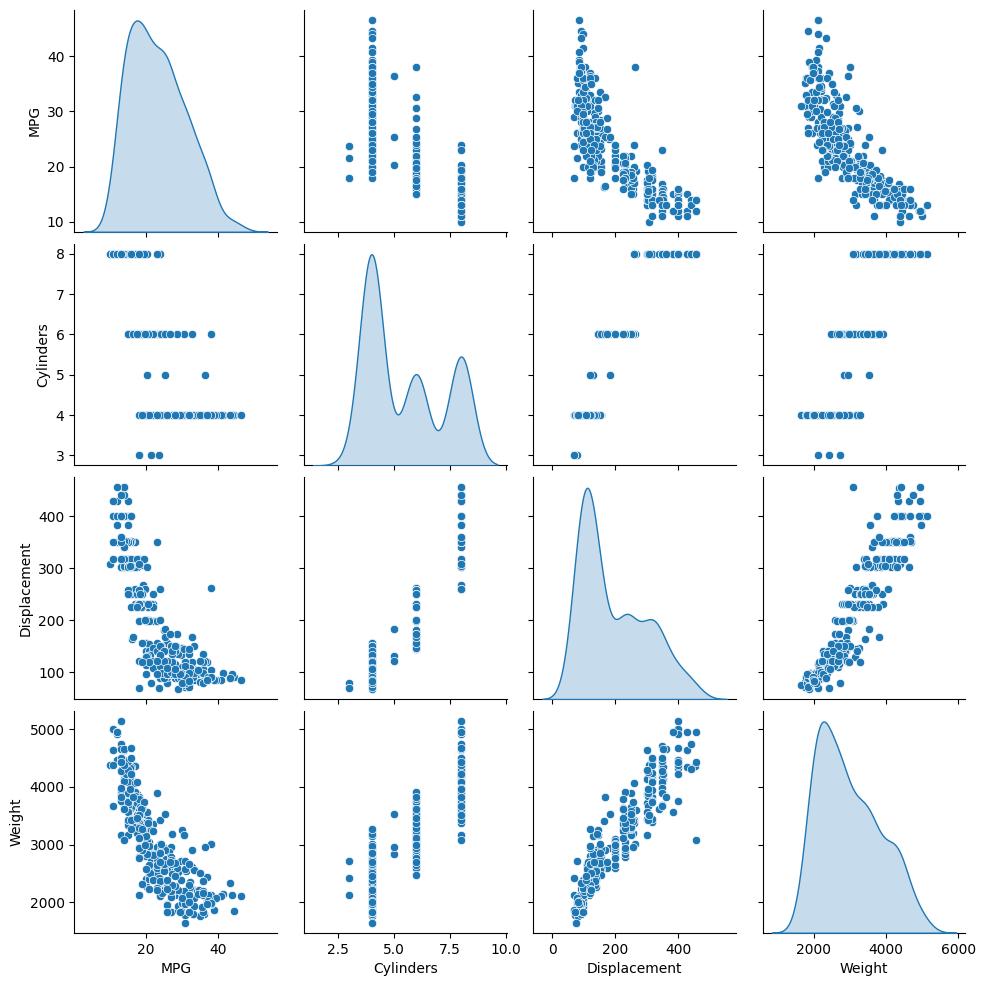

In [6]:
sns.pairplot(train_dataset[['MPG','Cylinders','Displacement','Weight']], diag_kind='kde')
plt.show()

## 3. Features, rótulos e normalização
Separamos o alvo (**MPG**) das features. Depois **normalizamos**: colocamos todas as variáveis na mesma escala. Sem isso, 'Weight' (milhares) dominaria 'Cylinders' (4 a 8) só por ser um número maior.

In [7]:
train_features = train_dataset.copy(); test_features = test_dataset.copy()
train_labels = train_features.pop('MPG'); test_labels = test_features.pop('MPG')

Xtr = np.array(train_features); Xte = np.array(test_features)
ytr = np.array(train_labels);   yte = np.array(test_labels)
hp_tr = np.array(train_features['Horsepower']).reshape(-1,1)
hp_te = np.array(test_features['Horsepower']).reshape(-1,1)
n_feat = Xtr.shape[1]

normalizer = layers.Normalization(axis=-1); normalizer.adapt(Xtr)
hp_norm = layers.Normalization(axis=None);  hp_norm.adapt(hp_tr)
print('Exemplo antes da normalizacao:', Xtr[0])
print('Exemplo depois  :', normalizer(Xtr[:1]).numpy()[0])

Exemplo antes da normalizacao: [   4.    90.    75.  2125.    14.5   74.     0.     0.     1. ]
Exemplo depois  : [-0.871 -1.011 -0.785 -1.027 -0.38  -0.517 -0.466 -0.496  0.776]


Função auxiliar para visualizar o erro caindo durante o treino:

In [8]:
def plot_loss(history, titulo):
    plt.figure(figsize=(7,4))
    plt.plot(history.history['loss'], label='treino')
    plt.plot(history.history['val_loss'], label='validacao')
    plt.ylim([0,10]); plt.xlabel('Epoca'); plt.ylabel('Erro [MPG]')
    plt.title(titulo); plt.legend(); plt.grid(True); plt.show()

resultados = {}  # guardaremos o erro de cada modelo no teste

## 4. Modelo 1 — Regressão linear com UMA variável (Horsepower)
O mais simples: uma reta. Prevê o MPG usando só a potência.

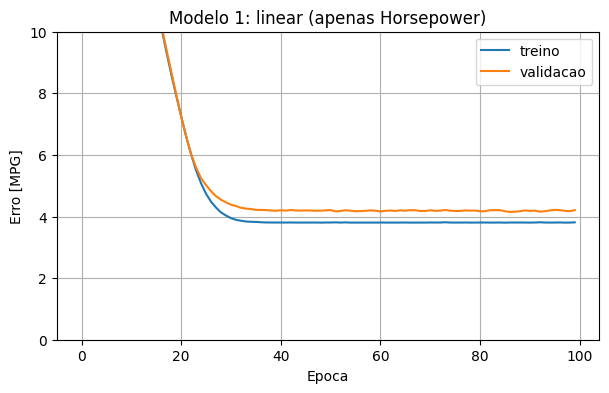

In [9]:
modelo_hp = keras.Sequential([keras.Input(shape=(1,)), hp_norm, layers.Dense(1)])
modelo_hp.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss='mean_absolute_error')
h = modelo_hp.fit(hp_tr, ytr, epochs=100, verbose=0, validation_split=0.2)
plot_loss(h, 'Modelo 1: linear (apenas Horsepower)')
resultados['1) linear (Horsepower)'] = modelo_hp.evaluate(hp_te, yte, verbose=0)

A reta aprendida, sobreposta aos dados reais:

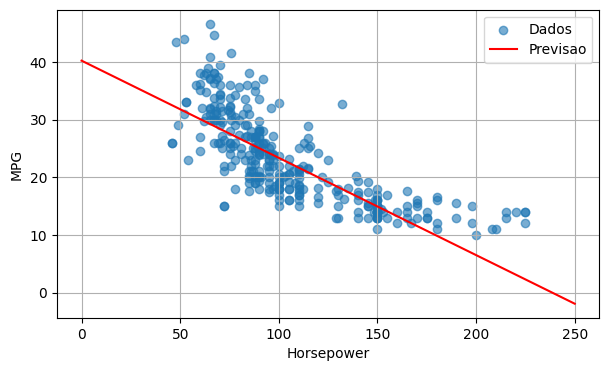

In [10]:
x = tf.linspace(0.0, 250, 251)
y = modelo_hp.predict(tf.reshape(x, (-1,1)), verbose=0)
plt.figure(figsize=(7,4))
plt.scatter(train_features['Horsepower'], train_labels, label='Dados', alpha=0.6)
plt.plot(x, y, color='red', label='Previsao')
plt.xlabel('Horsepower'); plt.ylabel('MPG'); plt.legend(); plt.grid(True); plt.show()

## 5. Modelo 2 — Regressão linear com TODAS as variáveis
Agora a reta vira um plano em várias dimensões: usa todas as features de uma vez.

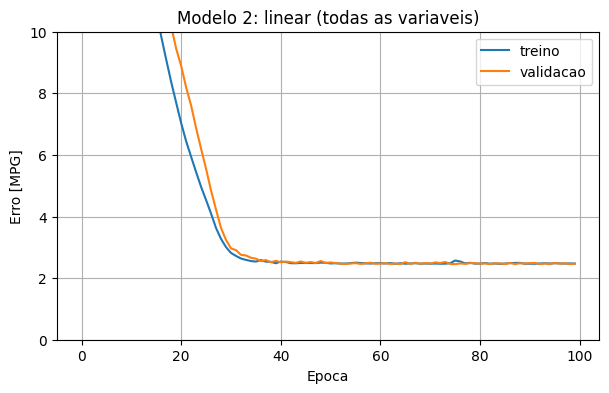

In [11]:
modelo_linear = keras.Sequential([keras.Input(shape=(n_feat,)), normalizer, layers.Dense(1)])
modelo_linear.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss='mean_absolute_error')
h = modelo_linear.fit(Xtr, ytr, epochs=100, verbose=0, validation_split=0.2)
plot_loss(h, 'Modelo 2: linear (todas as variaveis)')
resultados['2) linear (todas)'] = modelo_linear.evaluate(Xte, yte, verbose=0)

## 6. Modelos 3 e 4 — Rede Neural Profunda (DNN)
Aqui entram as **camadas ocultas** com ativação `relu`. Elas permitem aprender relações **não lineares** (curvas), que uma reta não consegue capturar.

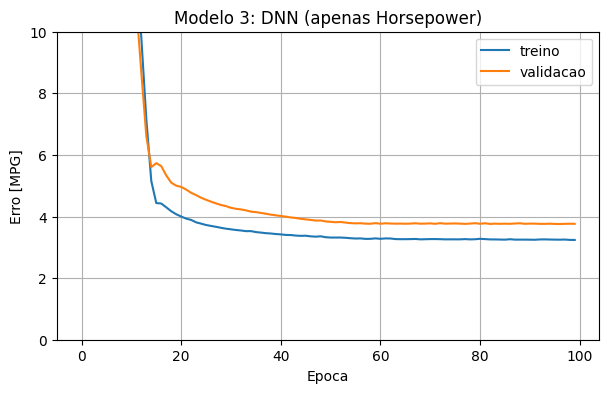

In [12]:
def build_dnn(norm, n):
    m = keras.Sequential([keras.Input(shape=(n,)), norm,
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)])
    m.compile(loss='mean_absolute_error', optimizer=tf.keras.optimizers.Adam(0.001))
    return m

dnn_hp = build_dnn(hp_norm, 1)
h = dnn_hp.fit(hp_tr, ytr, validation_split=0.2, verbose=0, epochs=100)
plot_loss(h, 'Modelo 3: DNN (apenas Horsepower)')
resultados['3) DNN (Horsepower)'] = dnn_hp.evaluate(hp_te, yte, verbose=0)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,884 (19.08 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 19 (80.00 B)

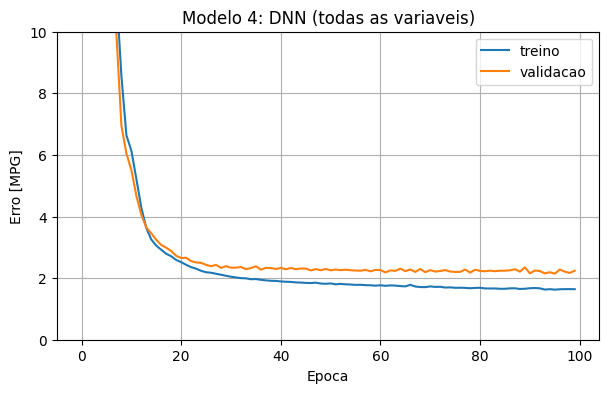

In [13]:
dnn_model = build_dnn(normalizer, n_feat)
dnn_model.summary()
h = dnn_model.fit(Xtr, ytr, validation_split=0.2, verbose=0, epochs=100)
plot_loss(h, 'Modelo 4: DNN (todas as variaveis)')
resultados['4) DNN (todas)'] = dnn_model.evaluate(Xte, yte, verbose=0)

## 7. Comparando os modelos
Erro médio absoluto (**MAE**) no conjunto de teste — quanto **menor**, melhor. É o erro médio, em MPG, das previsões.

In [14]:
pd.DataFrame(resultados, index=['MAE no teste [MPG]']).T.round(3)

,MAE no teste [MPG]
1) linear (Horsepower),3.656
2) linear (todas),2.480
3) DNN (Horsepower),2.915
4) DNN (todas),1.716


Repare na ordem: a rede profunda usando todas as variáveis erra bem menos que a reta simples. Mais informação + capacidade de aprender curvas = previsões melhores.

## 8. Qualidade das previsões do melhor modelo
Se as previsões fossem perfeitas, todos os pontos cairiam sobre a diagonal.

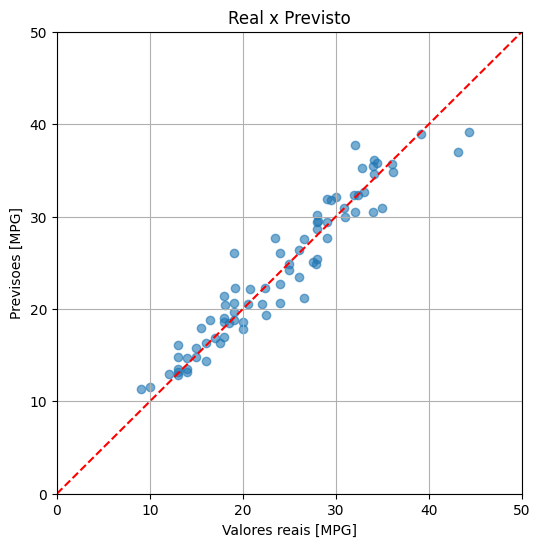

In [15]:
test_predictions = dnn_model.predict(Xte, verbose=0).flatten()
plt.figure(figsize=(6,6))
plt.scatter(yte, test_predictions, alpha=0.6)
lims = [0, 50]
plt.plot(lims, lims, 'r--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Valores reais [MPG]'); plt.ylabel('Previsoes [MPG]')
plt.title('Real x Previsto'); plt.grid(True); plt.show()

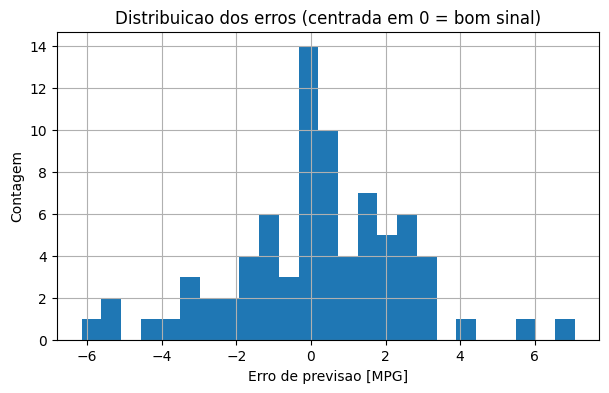

In [16]:
erros = test_predictions - yte
plt.figure(figsize=(7,4))
plt.hist(erros, bins=25)
plt.xlabel('Erro de previsao [MPG]'); plt.ylabel('Contagem')
plt.title('Distribuicao dos erros (centrada em 0 = bom sinal)'); plt.grid(True); plt.show()

## 9. Salvando o modelo
Modelos treinados podem ser salvos e recarregados depois, sem treinar de novo.

In [17]:
dnn_model.save('modelo_regressao_mpg.keras')
print('Modelo salvo em modelo_regressao_mpg.keras')

Modelo salvo em modelo_regressao_mpg.keras


### Conclusão
Saímos de uma reta (erro de ~3,6 MPG) até uma rede neural profunda (erro de ~1,6 MPG). A diferença entre regressão e classificação está na **última camada e na loss**: aqui a saída é um número e usamos *mean_absolute_error*; na classificação a saída seria uma probabilidade.